# How deep does a target need to be for a 100 % probability of detection?

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Method 1: Area Only

In this method we assume that the probability of detection is 1 when the area where the target would be illuminated exceeds that of the area where a specific facet is the closest. 


Assuming a square grid of facets, the area where a given facet is closest can be described as follows, where $l$ is the side length of the facet:
$$A_f = l^2$$

Then, the area where the target would be illuminated can be described as follows:
$$A_t = \pi(d\sin\theta)^2$$

Where $d$ and $\theta$ are target depth and the target "specular" beam width.


So the probability of detection here can be written as:
$$P = \frac{A_t}{A_f} = \frac{\pi(d\sin\theta)^2}{l^2}$$

So for a probability of 1, the depth of the target must be:
$$d = \frac{l}{\sin\theta\sqrt{\pi}}$$

### 1a. How does probability of detection change with depth?

In [2]:
# first lets do an example with the probability of detection
theta = np.radians(1)             # target beamwidth is 1 degree
l1    = 100                       # facet size [m]
l2    = 50                        # facet size [m]
d     = np.linspace(0, 4e3, 1000) # target depth [m] 

In [3]:
P1 = (np.pi * (d * np.sin(theta))**2) / l1**2
P2 = (np.pi * (d * np.sin(theta))**2) / l2**2

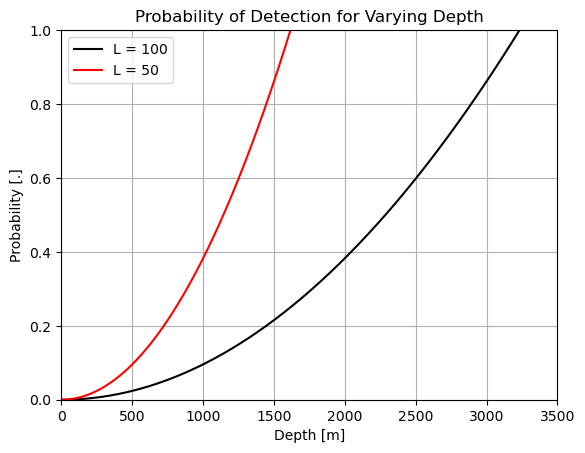

In [4]:
plt.plot(d, P1, color="black", label=f"L = {l1}")
plt.plot(d, P2, color="red", label=f"L = {l2}")
plt.ylim(0, 1)
plt.xlim(0, 3500)
plt.legend()
plt.title("Probability of Detection for Varying Depth")
plt.ylabel("Probability [.]")
plt.xlabel("Depth [m]")
plt.grid()
plt.show()

### 1b. When is detection guaranteed? ($P=1$)

In [5]:
l      = np.linspace(1, 150, 500) # facet size [m]
depth1 = l / (np.sin(theta) * np.sqrt(np.pi))

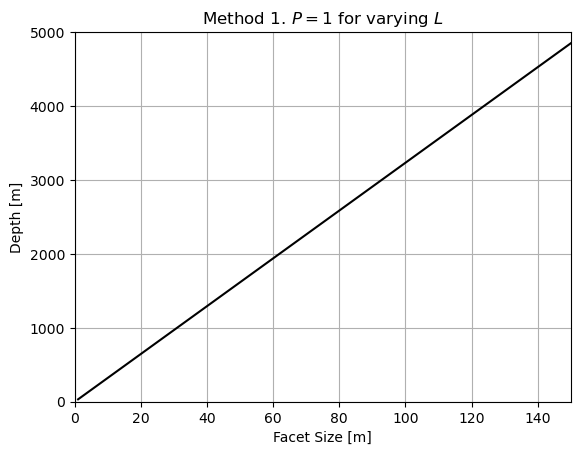

In [6]:
plt.plot(l, depth1, color="black")
plt.xlim(0, 150)
plt.ylim(0, 5000)
plt.title("Method 1. $P=1$ for varying $L$")
plt.ylabel("Depth [m]")
plt.xlabel("Facet Size [m]")
plt.grid()
plt.show()

Unfortunately this method is relaxed, ignoring the corners which are still not considered even when $P=1$ using this method. 

## Method 2: True Guaranteed Detection
This method corrects for the flaws of the previous one by saying that $P=1$ when the radius of the circle of illumination for a given depth is greater than the diagonal. We can solve for the depth at which detection is guaranteed as follows:

$$d\sin\theta = l\sqrt{2}$$
$$d=\frac{l\sqrt{2}}{\sin\theta}$$

In [7]:
l      = np.linspace(1, 150, 500) # facet size [m]
depth2 = (l * np.sqrt(2)) / np.sin(theta)

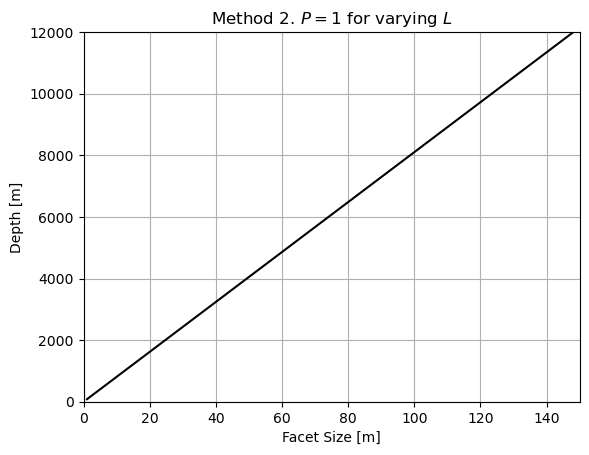

In [8]:
plt.plot(l, depth2, color="black")
plt.xlim(0, 150)
plt.ylim(0, 12000)
plt.title("Method 2. $P=1$ for varying $L$")
plt.ylabel("Depth [m]")
plt.xlabel("Facet Size [m]")
plt.grid()
plt.show()

## Comparison of Method 1 vs 2:

Rate of depth increase per facet size:  
**Method 1: 32.32**  
**Method 2: 81.03**

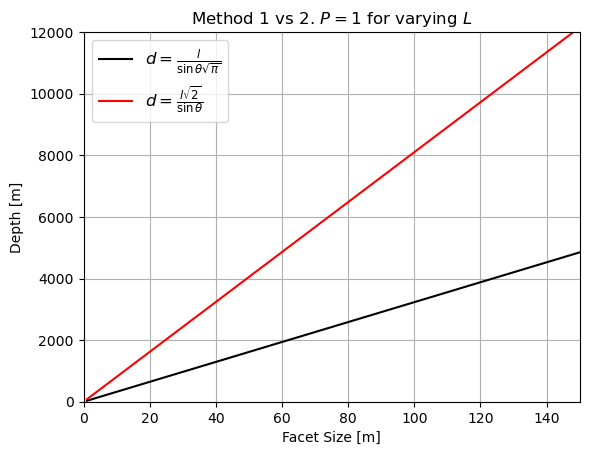

In [9]:
plt.plot(l, depth1, color="black", label=r"$d=\frac{l}{\sin\theta\sqrt{\pi}}$")
plt.plot(l, depth2, color="red", label=r"$d=\frac{l\sqrt{2}}{\sin\theta}$")
plt.xlim(0, 150)
plt.ylim(0, 12000)
plt.title("Method 1 vs 2. $P=1$ for varying $L$")
plt.ylabel("Depth [m]")
plt.xlabel("Facet Size [m]")
plt.legend(fontsize=12)
plt.grid()
plt.show()

## What is the rate of depth increase for each facet size in each method?

In [10]:
thetas = np.radians(np.linspace(0.1, 7.5, 200))
rate1  = 1 / (np.sin(thetas) * np.sqrt(np.pi))
rate2  = np.sqrt(2) / np.sin(thetas)

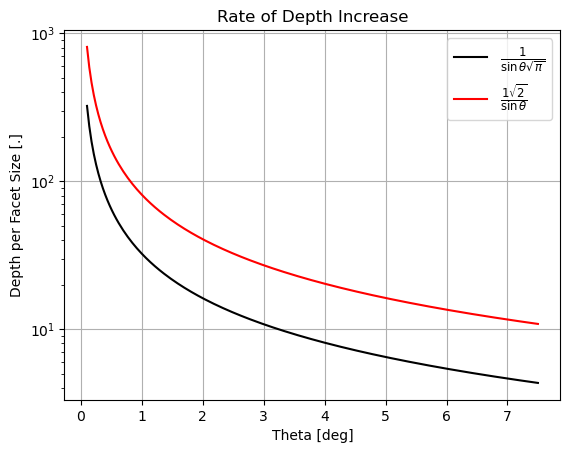

In [13]:
plt.plot(np.degrees(thetas), rate1, color="black", label=r"$\frac{1}{\sin\theta\sqrt{\pi}}$")
plt.plot(np.degrees(thetas), rate2, color="red", label=r"$\frac{1\sqrt{2}}{\sin\theta}$")
plt.title("Rate of Depth Increase")
plt.ylabel("Depth per Facet Size [.]")
plt.xlabel("Theta [deg]")
plt.yscale("log")
plt.legend(fontsize=12)
plt.grid()
plt.show()